# AICE Associate 실전 모의고사 - 다중분류

## 온라인 쇼핑 고객 행동 데이터를 활용한 고객 유형 예측

**도메인:** 이커머스 / CRM  
**목표:** 고객 행동 데이터를 이용하여 고객 유형(`customer_segment`)을 예측하는 다중분류 AI 모델 개발

쇼핑몰 A사는 고객 행동에 맞춘 마케팅 정책을 적용하기 위해 고객을 여러 유형으로 분류하고 있습니다.  
최근 고객 수가 증가하면서 수작업 분류가 어려워져, 접속·구매·할인 사용·회원등급 등의 데이터를 이용해 고객 유형을 자동 예측하는 모델을 만들려고 합니다.

### 유의사항
- 각 문항의 답안은 반드시 지정된 답안 셀에 작성하세요.
- 문항에서 변수명을 지정한 경우 **반드시 해당 변수명**을 사용하세요.
- 이전 문항의 처리 결과를 다음 문항에서 계속 사용합니다.
- 문제에서 요구하지 않은 불필요한 출력은 하지 않아도 됩니다.
- 일부 문항은 오류 코드 수정, 빈칸 완성 형식입니다.
- 실제 시험처럼 먼저 스스로 풀고, 막히는 부분만 표시해 두는 것을 권장합니다.

### 데이터 컬럼
- `customer_id` : 고객 ID
- `signup_date` : 가입일
- `age` : 나이
- `monthly_visits` : 월 평균 방문 횟수
- `avg_session_min` : 평균 체류시간(분)
- `cart_adds` : 장바구니 추가 횟수
- `purchase_count` : 구매 횟수
- `return_rate` : 반품 비율
- `discount_usage` : 할인 사용 비율
- `days_since_last_visit` : 마지막 방문 후 경과일
- `device_type` : 주 이용 기기
- `membership` : 회원등급
- `region` : 지역
- `preferred_category` : 선호 상품군
- `contact_channel` : 마케팅 수신 채널
- `customer_segment` : 고객 유형 **(예측 대상, 4개 클래스)**


## <데이터 분석 (20점)>

### 1. 라이브러리 불러오기
다음 분석에서 사용할 `numpy`, `pandas`, `seaborn`, `matplotlib.pyplot`을 각각 일반적으로 사용하는 별칭으로 불러오세요.

In [1]:
# 여기에 답안코드를 작성하고 실행하세요
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### 2. 데이터 불러오기
`customer_behavior_multiclass.csv` 파일을 읽어 데이터프레임 `data`에 저장하고 첫 4개 행을 확인하세요.

In [46]:
# 여기에 답안코드를 작성하고 실행하세요
data = pd.read_csv('customer_behavior_multiclass.csv')
data.head(4)

,customer_id,signup_date,age,monthly_visits,avg_session_min,cart_adds,purchase_count,return_rate,discount_usage,days_since_last_visit,device_type,membership,region,preferred_category,contact_channel,customer_segment
0,CUST-000001,2022-04-05,34.0,8,7.15,5,4,0.023,0.296,20.8,mobile,Basic,Daegu,fashion,email,Loyal
1,CUST-000002,2022-04-30,40.0,11,13.56,5,6,0.064,0.225,23.7,desktop,Basic,Seoul,electronics,email|sms,Bargain
2,CUST-000003,2023-03-07,32.0,5,12.45,2,5,0.095,0.576,1.9,mobile,Basic,Gyeonggi,home,email,Loyal
3,CUST-000004,2023-06-21,49.0,9,32.01,8,1,0.102,0.647,7.7,mobile,Silver,Gyeonggi,fashion,push,Explorer


### 3. 고객 유형 및 수치형 변수 분포 확인
`subplots`를 사용하여 그래프 2개를 가로로 배치하세요.

- 왼쪽: `customer_segment`의 분포를 나타내는 countplot
- 오른쪽: 고객 유형별 `monthly_visits` 분포를 비교하는 boxplot
- 그래프 제목은 각각 `Segment Count`, `Monthly Visits`로 지정하세요.


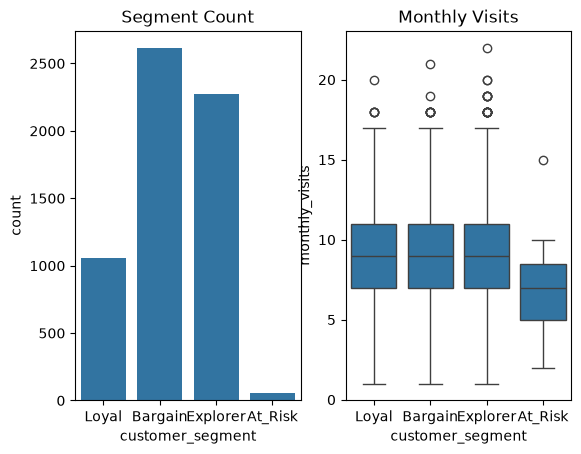

In [ ]:
# 여기에 답안코드를 작성하고 실행하세요
fig, axes = plt.subplots(1, 2)

sns.countplot(data=data, x='customer_segment', ax=axes[0])
# 고객 유형별 월 방문 빈도
sns.boxplot(data=data, x='customer_segment', y='monthly_visits' , ax=axes[1])

axes[0].set_title('Segment Count')
axes[1].set_title('Monthly Visits')

plt.show()

### 4. 체류시간과 구매횟수의 관계 확인
`avg_session_min`과 `purchase_count`의 관계를 산점도로 확인하세요.

- X축: `avg_session_min`
- Y축: `purchase_count`
- 고객 유형(`customer_segment`)에 따라 점을 구분하세요.


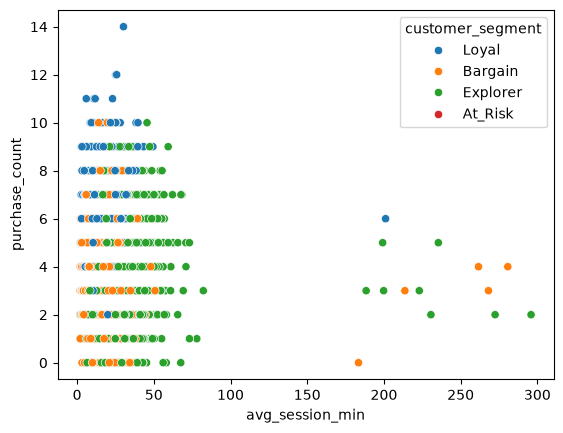

In [7]:
# 여기에 답안코드를 작성하고 실행하세요
sns.scatterplot(data=data, x='avg_session_min', y='purchase_count', hue='customer_segment')

plt.show()

## <데이터 전처리 (30점)>

### 5. 이상치 및 불필요 컬럼 처리
시각화 결과 `avg_session_min`에 비정상적으로 큰 값이 포함되어 있다고 판단했습니다.

- `avg_session_min`이 **150 이상인 행**을 제거하세요.
- 모델링에 불필요한 `customer_id` 컬럼을 제거하세요.
- 처리 결과는 `data_temp`에 저장하세요.
- 삭제 후 인덱스를 0부터 다시 정렬하세요.


In [8]:
# 여기에 답안코드를 작성하고 실행하세요
data = data.drop(data[data['avg_session_min']>=150].index, axis=0).reset_index(drop=True)
data = data.drop(columns='customer_id')
data_temp = data.copy()

### 6. 결측치 처리
`data_temp`의 결측치를 확인한 뒤, 결측치가 존재하는 행을 모두 제거하여 `data_na`에 저장하세요.

아래 코드에는 오류가 있습니다. 수정해서 실행하세요.


In [9]:
# (6) 오류를 정정하고 실행하세요
data_na = data_temp.dropna()
data_na.isnull().sum()


signup_date              0
age                      0
monthly_visits           0
avg_session_min          0
cart_adds                0
purchase_count           0
return_rate              0
discount_usage           0
days_since_last_visit    0
device_type              0
membership               0
region                   0
preferred_category       0
contact_channel          0
customer_segment         0
dtype: int64

### 7. 범주값 정리
`contact_channel`에는 여러 채널을 동시에 사용하는 값이 들어 있습니다.

다음 값들은 모두 `'multi'`로 치환하세요.

`'email|push'`, `'email|sms'`, `'push|sms'`, `'email|push|sms'`

- `isin()`과 `loc`를 사용하세요.
- 처리 후 `contact_channel`의 카테고리별 개수를 확인하세요.


In [16]:
# 여기에 답안코드를 작성하고 실행하세요
data_na.loc[data_na['contact_channel'].isin(['email|push', 'email|sms', 'push|sms', 'email|push|sms']), 'contact_channel'] = 'multi'
data_na['contact_channel'].value_counts()

contact_channel
multi    1963
email    1588
push     1354
sms      1011
Name: count, dtype: int64

### 8. 날짜 파생변수 및 원-핫 인코딩
`signup_date`를 날짜형으로 변환한 뒤 다음 파생변수를 만드세요.

- `signup_year`
- `signup_month`

이후 원본 `signup_date` 컬럼은 삭제하세요.

다음 범주형 컬럼을 원-핫 인코딩하여 결과를 `data_preset`에 저장하세요.

`device_type`, `membership`, `region`, `preferred_category`, `contact_channel`

`customer_segment`는 이 단계에서 원-핫 인코딩하지 않습니다.


In [18]:
# 여기에 답안코드를 작성하고 실행하세요
data_na['signup_date'] = pd.to_datetime(data_na['signup_date'])
data_na['signup_year'] = data_na['signup_date'].dt.year
data_na['signup_month'] = data_na['signup_date'].dt.month

data_na = data_na.drop(columns='signup_date')

data_preset = pd.get_dummies(data_na, columns=['device_type', 'membership', 'region', 'preferred_category', 'contact_channel'], dtype=int)



### 9. X/y 분리, LabelEncoder, train/valid 분리
예측 대상은 `customer_segment`입니다.

- 입력 데이터는 `X`, 레이블은 `y`로 지정하세요.
- `LabelEncoder`를 사용하여 레이블을 정수형으로 변환하세요.
- LabelEncoder 객체 변수명은 `le`로 지정하세요.
- 변환된 레이블은 다시 `y`에 저장하세요.
- 훈련:검증 비율은 75:25
- 난수 시드: 42
- 클래스 비율을 유지하도록 설정
- 결과 변수명: `X_train`, `X_valid`, `y_train`, `y_valid`


In [19]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = data_preset.drop(columns=['customer_segment'])
y = data_preset['customer_segment']

le = LabelEncoder()

y = le.fit_transform(y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)



### 10. StandardScaler 적용
LogisticRegression 및 딥러닝 학습을 위해 수치 스케일을 맞추려고 합니다.

아래 오류 코드를 수정하세요.

- `StandardScaler` 객체 변수명: `ss`
- 훈련 데이터에는 학습과 변환을 함께 적용
- 검증 데이터에는 훈련 데이터에서 학습된 기준으로 변환만 적용
- 결과 변수명: `X_train_scaled`, `X_valid_scaled`


In [21]:
# (10) 오류를 정정하고 실행하세요
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)


## <AI 모델링 (50점)>

### 11. 다중분류 모델 학습 및 GridSearchCV
두 모델을 학습하세요.

**(11-1) LogisticRegression**
- 스케일링된 데이터 사용
- `max_iter=1000`
- 난수 시드가 지원되는 경우 `random_state=42`
- 모델 변수명: `lr`

**(11-2) RandomForest + GridSearchCV**
- 스케일링 전 `X_train` 사용
- RandomForest 난수 시드: 42
- 후보 파라미터  
  - `n_estimators`: [100, 200]
  - `max_depth`: [6, 10]
  - `min_samples_split`: [2, 5]
- Cross Validation: 4회
- scoring: `f1_macro`
- n_jobs: -1
- GridSearchCV 변수명: `gs_rf`
- 훈련 데이터로 학습하세요.


In [31]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

rf = RandomForestClassifier(random_state=42)

params = {
    'n_estimators':[100, 200],
    'max_depth':[6, 10],
    'min_samples_split':[2, 5]
}

gs_rf = GridSearchCV(
    rf,
    params,
    cv=4,
    scoring='f1_macro',
    n_jobs=-1
)

lr.fit(X_train_scaled, y_train);
gs_rf.fit(X_train, y_train);

### 12. 모델 평가
검증 데이터에 대해 두 모델을 평가하세요.

- LogisticRegression은 `X_valid_scaled` 사용
- RandomForest는 `gs_rf.best_estimator_`와 `X_valid` 사용
- 예측값 변수명은 각각 `y_pred_lr`, `y_pred_rf`
- 두 모델의 `accuracy`와 `macro F1-score`를 계산하세요.
- 네 개의 평가값만 한 번에 확인하면 됩니다.

추가로, **macro F1-score가 더 높은 모델의 이름**을 아래 답안 셀에 적으세요.


In [32]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.metrics import accuracy_score, f1_score

best_rf_model = gs_rf.best_estimator_

y_pred_lr = lr.predict(X_valid_scaled)
y_pred_rf = best_rf_model.predict(X_valid)

print('lr : ', accuracy_score(y_valid, y_pred_lr), f1_score(y_valid, y_pred_lr, average='macro'))
print('rf : ', accuracy_score(y_valid, y_pred_rf), f1_score(y_valid, y_pred_rf, average='macro'))


lr :  0.6274509803921569 0.5539971878145927
rf :  0.6186612576064908 0.4391573155441433


In [ ]:
# (12-2) 여기에 답안을 입력하세요. 실행은 필요 없습니다.
# LogisticRegression

### 13. 최적 RandomForest 분석
GridSearchCV에서 찾은 최적 모델을 이용합니다.

**(13-1)** `gs_rf.best_params_`를 확인하세요.

**(13-2)** 최적 모델의 변수중요도를 데이터프레임 `fi`로 만들고 중요도 기준 내림차순 Top 10을 막대그래프로 시각화하세요.

- 컬럼명: `feature`, `importance`
- 모델은 `gs_rf.best_estimator_`를 사용하세요.


{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


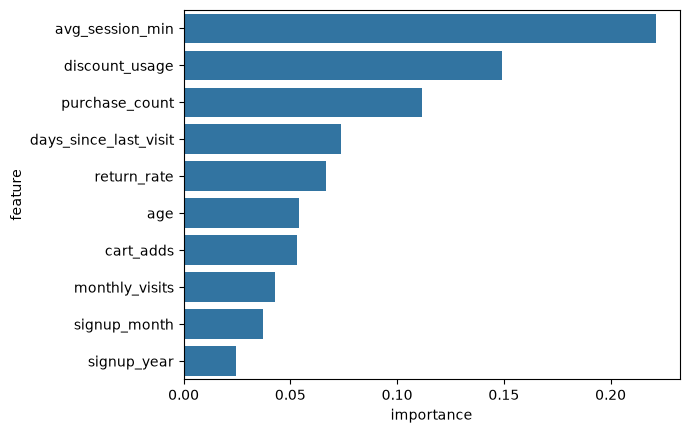

In [34]:
# 여기에 답안코드를 작성하고 실행하세요
print(gs_rf.best_params_)

fi = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf_model.feature_importances_
})

fi = fi.sort_values('importance', ascending=False).head(10)

sns.barplot(data=fi, x='importance', y='feature')
plt.show()

### 14. 다중분류 딥러닝 모델
앞서 만든 **정수형 레이블** `y_train`, `y_valid`를 그대로 사용하여 다중분류 딥러닝 모델을 학습하세요.

#### 모델 구조
- 입력층 크기: 학습 데이터의 feature 수
- Dense 64, activation=`relu`
- Dropout 0.2
- Dense 32, activation=`relu`
- 출력층: 클래스 개수만큼의 unit, activation=`softmax`

#### 학습 조건
- 클래스 개수는 `len(np.unique(y_train))`로 계산하여 `num_classes`에 저장
- optimizer: `adam`
- loss: **정수형 다중분류 레이블에 맞는 loss**
- metrics: `accuracy`
- EarlyStopping: `val_loss`, patience=7, `restore_best_weights=True`
- ModelCheckpoint: `val_loss`, 파일명 `best_multiclass_model.keras`, `save_best_only=True`
- epochs=60
- batch_size=64
- validation_data는 검증 데이터를 직접 지정
- callbacks에는 EarlyStopping과 ModelCheckpoint를 모두 사용
- 학습 결과는 `history`에 저장

마지막으로 저장된 best model을 다시 불러와 `best_model`에 저장하고, 검증 데이터의 loss와 accuracy를 평가하세요.


In [42]:
# 여기에 답안코드를 작성하고 실행하세요
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

num_classes = len(np.unique(y_train))

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

estop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    filepath='best_multiclass_model.keras',
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=60,
    batch_size=64,
    validation_data=(X_valid_scaled, y_valid),
    callbacks=[estop, checkpoint]
)

Epoch 1/60


c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4453 - loss: 1.1578 - val_accuracy: 0.5713 - val_loss: 0.9475
Epoch 2/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5625 - loss: 0.9386 - val_accuracy: 0.6092 - val_loss: 0.8624
Epoch 3/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6009 - loss: 0.8891 - val_accuracy: 0.6126 - val_loss: 0.8386
Epoch 4/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6142 - loss: 0.8535 - val_accuracy: 0.6166 - val_loss: 0.8240
Epoch 5/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6247 - loss: 0.8365 - val_accuracy: 0.6261 - val_loss: 0.8168
Epoch 6/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6130 - loss: 0.8289 - val_accuracy: 0.6261 - val_loss: 0.8083
Epoch 7/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6238 - loss: 0.8169 - val_accuracy: 0.6193 - val_loss: 0.8033
Epoch 8/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6329 - loss: 0.8047 - val_accuracy: 0.6153 - val_loss: 0.8045
Epo

In [ ]:
# 모델 불러와서 검증
best_model = load_model('best_multiclass_model.keras')

loss, accuracy = best_model.evaluate(
    X_valid_scaled,
    y_valid
)

print(loss, accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6180 - loss: 0.7950  
0.7950077652931213 0.6179851293563843


### 15. 학습 과정 시각화
딥러닝 학습 결과에서 `accuracy`와 `val_accuracy`를 하나의 그래프에 표시하세요.

- 제목: `Model Accuracy`
- X축: `Epoch`
- Y축: `Accuracy`
- 범례: `accuracy`, `val_accuracy`

불필요한 추가 출력은 하지 않습니다.


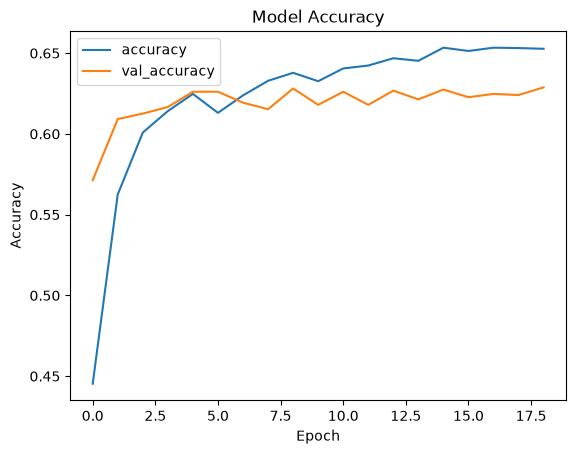

In [45]:
# 여기에 답안코드를 작성하고 실행하세요
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.title('Model Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

---

## 종료 전 체크
문제를 모두 풀었다면 다음만 확인하세요.

- 데이터 전처리 결과를 변수에 제대로 저장했는가?
- `LabelEncoder`에서 train/valid를 따로 `fit`하지 않았는가?
- `StandardScaler`를 검증 데이터에 다시 `fit`하지 않았는가?
- GridSearchCV 평가 시 `best_estimator_`를 사용했는가?
- 다중분류 출력층이 `softmax`이며 클래스 수와 unit 수가 일치하는가?
- 정수형 레이블을 그대로 사용했다면 loss가 그 형태에 맞는가?
- `ModelCheckpoint`가 저장한 모델을 실제로 다시 불러왔는가?

**정답 코드는 포함되어 있지 않습니다.**
